# LLH model exploration

Two aims:

1. **Visualise the three state variables** $(S_t,\sigma_t,\theta_t)$ side by side under both table-parameter sets, to build intuition for how the SDE system actually behaves.
2. **Diagnose why the European price appears convex in $\lambda$** (cf. `figs/fig4a_price_vs_lambda_*.png`). Below we lay out a decomposition experiment that isolates the mechanism.

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt

import priceModels as pm

# Canonical parameter sets (mirrors generate_plots.PARAM_SETS)
PARAM_SETS = {
    'T1': dict(r=0.01, rho=-0.2, kappa=5, nu=0.2,
               sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01),
    'T2': dict(r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
               sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112),
}
LABELS = {'T1': 'Table 1', 'T2': 'Table 2'}

S0   = 100.0
T    = 1.0
N_STEPS_MC = 252
N_PATHS    = 5_000
N_SHOW     = 50            # paths drawn for the sample-path figure
SEED       = 42

print('imports OK')

imports OK


## 1. State-variable sample paths, one row per parameter set

For each table we simulate `N_PATHS` trajectories of $(S_t,\sigma_t,\theta_t)$ over $[0,T]$ and draw `N_SHOW` of them. A heavy mean line ($E[\cdot]$ across all paths) is overlaid in each panel to show where the bulk of the distribution sits.

Recall the LLH SDE system (with `theta_driver='bm'` — the PDE-consistent form):

$$
dS_t = r S_t \, dt + \sigma_t S_t\, dW^{(S)}_t,\qquad
d\sigma_t = \kappa(\theta_t - \sigma_t)\, dt + \nu\, dW^{(\sigma)}_t,\qquad
d\theta_t = \lambda\, dt + \eta\, dW^{(\theta)}_t.
$$

Note: $\theta$ has **no mean reversion** and a pure linear drift $\lambda$. That structural asymmetry is what makes the $\lambda$-sensitivity non-trivial.

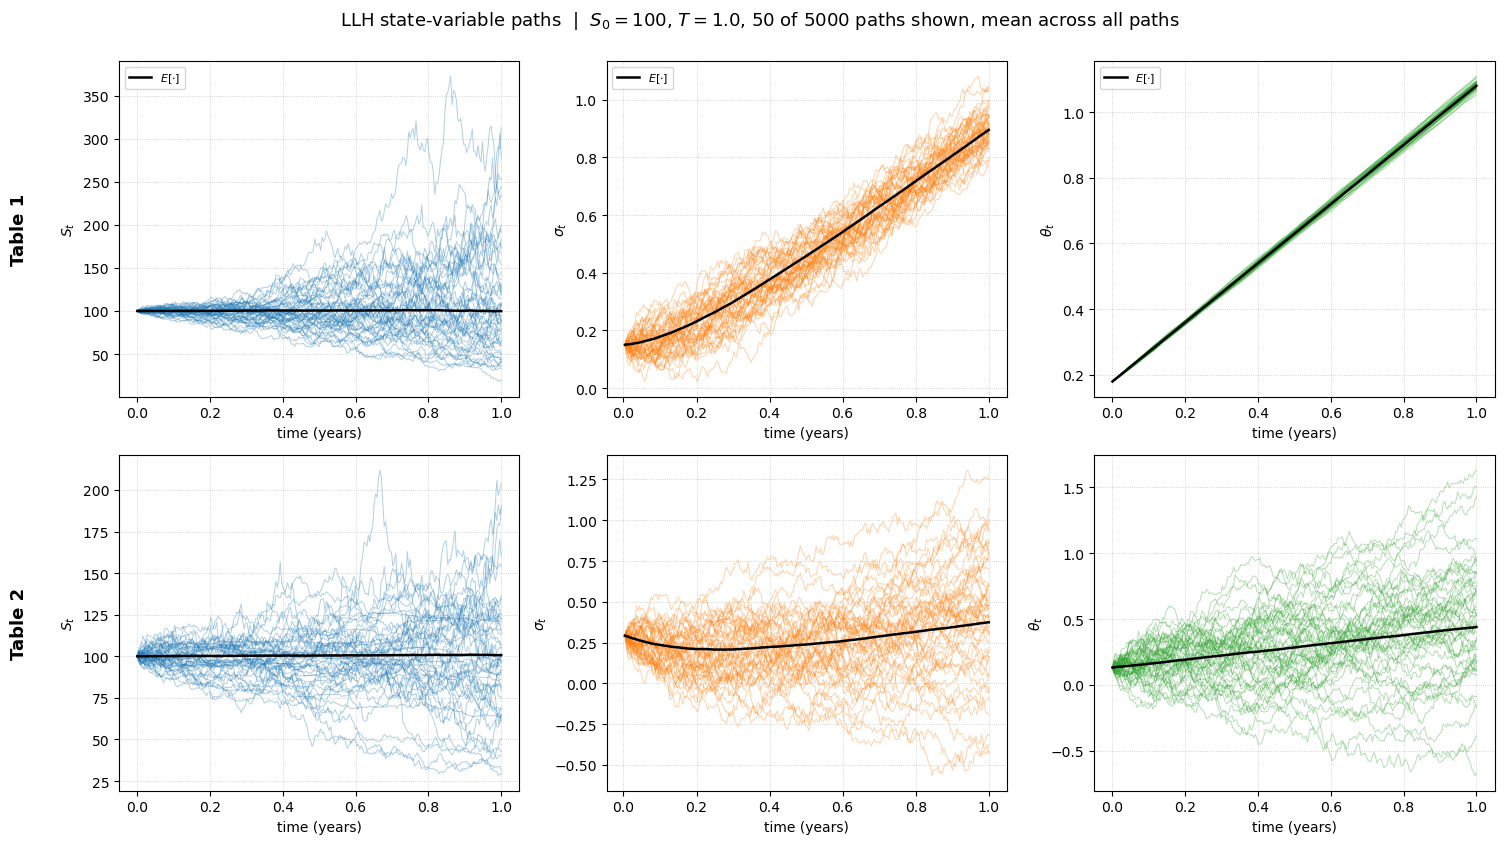

In [21]:
var_specs = [
    ('S',     r'$S_t$',      '#1f77b4'),
    ('sigma', r'$\sigma_t$', '#ff7f0e'),
    ('theta', r'$\theta_t$', '#2ca02c'),
]

# Deterministic random sub-sample of path indices (reproducible across re-runs).
show_idx = np.random.default_rng(SEED).choice(N_PATHS, size=N_SHOW, replace=False)

fig, axes = plt.subplots(len(PARAM_SETS), 3,
                         figsize=(15, 4.2 * len(PARAM_SETS)),
                         sharex=False)

for i, (name, params) in enumerate(PARAM_SETS.items()):
    model = pm.ImprovedSteinStein(**params, seed=SEED)
    sim = model.simulate_prices(
        S0=S0, T=T, n_steps_mc=N_STEPS_MC, n_paths=N_PATHS,
        scheme='euler', theta_driver='bm',
    )
    dt = sim['dt']
    # sigma_hat[:, j] drives S[:, j] -> S[:, j+1]; plot it at the right endpoint.
    arrays = {
        'S'    : (sim['S'],         np.arange(N_STEPS_MC + 1) * dt),
        'sigma': (sim['sigma_hat'], (np.arange(N_STEPS_MC) + 1) * dt),
        'theta': (sim['theta'],     np.arange(N_STEPS_MC + 1) * dt),
    }

    for j, (key, ylabel, color) in enumerate(var_specs):
        ax = axes[i, j] if len(PARAM_SETS) > 1 else axes[j]
        arr, t = arrays[key]
        ax.plot(t, arr[show_idx].T, color=color, lw=0.7, alpha=0.35)
        ax.plot(t, arr.mean(axis=0), color='black', lw=1.8, label=r'$E[\cdot]$')
        ax.set_xlabel('time (years)')
        ax.set_ylabel(ylabel)
        ax.grid(True, ls=':', lw=0.6, alpha=0.7)
        if j == 0:
            ax.text(-0.25, 0.5, LABELS[name], transform=ax.transAxes,
                    fontsize=13, rotation=90, va='center', ha='center',
                    fontweight='bold')
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)

fig.suptitle(
    f'LLH state-variable paths  |  $S_0={S0:.0f}$, $T={T}$, '
    f'{N_SHOW} of {N_PATHS} paths shown, mean across all paths',
    fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

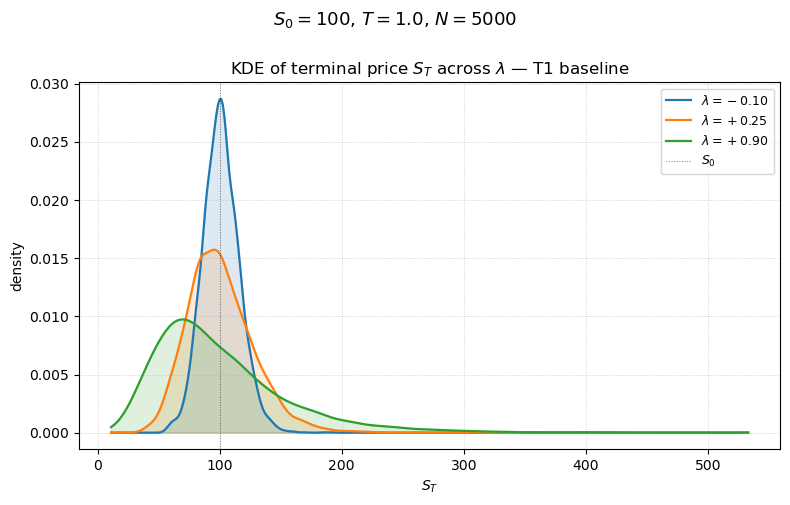

In [22]:
from scipy.stats import gaussian_kde

# Lambda sweep on top of T1 baseline; all other params held fixed.
T1_BASE     = PARAM_SETS['T1']
LAM_VALUES  = [-0.1, 0.25, 0.9]
LAM_COLORS  = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Simulate once per lambda, keep the terminal slice only.
S_T_by_lam = {}
for lam in LAM_VALUES:
    params = dict(T1_BASE); params['lam'] = lam
    model = pm.ImprovedSteinStein(**params, seed=SEED)
    sim = model.simulate_prices(
        S0=S0, T=T, n_steps_mc=N_STEPS_MC, n_paths=N_PATHS,
        scheme='euler', theta_driver='bm',
    )
    S_T_by_lam[lam] = sim['S'][:, -1]

fig, ax = plt.subplots(figsize=(8, 5))

# Common x-grid for fair overlay across the three lambda densities
all_ST = np.concatenate(list(S_T_by_lam.values()))
grid   = np.linspace(all_ST.min(), all_ST.max(), 400)
for (lam, S_T), color in zip(S_T_by_lam.items(), LAM_COLORS):
    dens = gaussian_kde(S_T)(grid)
    ax.plot(grid, dens, color=color, lw=1.6, label=rf'$\lambda = {lam:+.2f}$')
    ax.fill_between(grid, dens, color=color, alpha=0.15)

ax.axvline(S0, color='k', ls=':', lw=0.7, alpha=0.5, label=r'$S_0$')
ax.set_xlabel(r'$S_T$')
ax.set_ylabel('density')
ax.set_title(r'KDE of terminal price $S_T$ across $\lambda$ — T1 baseline')
ax.legend(loc='best', fontsize=9)
ax.grid(True, ls=':', lw=0.6, alpha=0.7)

fig.suptitle(
    f'$S_0={S0:.0f}$, $T={T}$, $N={N_PATHS}$',
    fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

In [ ]:
from scipy.stats import gaussian_kde

# Re-simulate once per param set; full paths feed panel (A), terminal slice feeds (B).
sims = {}
for name, params in PARAM_SETS.items():
    model = pm.ImprovedSteinStein(**params, seed=SEED)
    sims[name] = model.simulate_prices(
        S0=S0, T=T, n_steps_mc=N_STEPS_MC, n_paths=N_PATHS,
        scheme='euler', theta_driver='bm',
    )

# Deterministic random sub-sample of path indices (reproducible across re-runs).
show_idx = np.random.default_rng(SEED).choice(N_PATHS, size=N_SHOW, replace=False)

fig, (ax_paths, ax_kde) = plt.subplots(1, 2, figsize=(14, 5))
palette = {'T1': '#1f77b4', 'T2': '#d62728'}

# (A) Sample paths + mean, T1 vs T2 overlaid
for name, sim in sims.items():
    S  = sim['S']
    t  = np.arange(S.shape[1]) * sim['dt']
    c  = palette[name]
    ax_paths.plot(t, S[show_idx].T, color=c, lw=0.6, alpha=0.20)
    ax_paths.plot(t, S.mean(axis=0), color=c, lw=1.8,
                  label=f'{LABELS[name]}: $E[S_t]$')
ax_paths.axhline(S0, color='k', ls=':', lw=0.7, alpha=0.5)
ax_paths.set_xlabel('t (years)')
ax_paths.set_ylabel(r'$S_t$')
ax_paths.set_title(f'(A) {N_SHOW} of {N_PATHS} sample paths, T1 vs T2')
ax_paths.legend(loc='best', fontsize=9)
ax_paths.grid(True, ls=':', lw=0.6, alpha=0.7)

# (B) KDE of terminal price S_T, common x-grid for fair comparison
all_ST = np.concatenate([sim['S'][:, -1] for sim in sims.values()])
grid   = np.linspace(all_ST.min(), all_ST.max(), 400)
for name, sim in sims.items():
    S_T = sim['S'][:, -1]
    kde = gaussian_kde(S_T)
    dens = kde(grid)
    c = palette[name]
    ax_kde.plot(grid, dens, color=c, lw=1.6, label=LABELS[name])
    ax_kde.fill_between(grid, dens, color=c, alpha=0.15)
ax_kde.axvline(S0, color='k', ls=':', lw=0.7, alpha=0.5, label=r'$S_0$')
ax_kde.set_xlabel(r'$S_T$')
ax_kde.set_ylabel('density')
ax_kde.set_title(r'(B) KDE of terminal price $S_T$')
ax_kde.legend(loc='best', fontsize=9)
ax_kde.grid(True, ls=':', lw=0.6, alpha=0.7)

fig.suptitle(
    f'Price comparison T1 vs T2  |  $S_0={S0:.0f}$, $T={T}$, $N={N_PATHS}$',
    fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

**What to look for.** In both rows $E[\theta_t]$ should trace a straight line with slope $\lambda$ — that is the only drift acting on $\theta$ under the 'bm' driver. $E[\sigma_t]$ should rise toward $\theta_t$ at speed $\kappa$ (fast for T1 with $\kappa{=}5$, similarly fast for T2). The path dispersion is governed by $\nu$ and $\eta$; T2's larger $\eta=0.41$ should produce visibly wider $\theta$-fans than T1's $\eta=0.01$.

The linearity of $E[\theta_t]$ in $t$ (and therefore in $\lambda t$) is exactly the feature that feeds into the next section.

## 2. Why does the European price appear convex in $\lambda$?

Empirically, `plot_llh_vs_sz_lambda` produces a visibly **convex-up** curve of the European call price against $\lambda$ at $S_0=K=100$. A plausible mechanism:

- Under the 'bm' driver, $\theta_t \approx \theta_0 + \lambda t$ in mean, and $\sigma_t$ is pulled toward $\theta_t$ at speed $\kappa$. So $E[\sigma_t]$ scales **linearly** in $\lambda$ (affinely in $(\theta_0, \lambda)$).
- The integrated variance $V_T := \int_0^T \sigma_s^2\, ds$ has expectation that includes a term $\propto \lambda^2 T^3/3$ (from squaring the affine trajectory). So $E[V_T]$ is **quadratic** in $\lambda$ — that is where the convexity enters.
- Through the pricing kernel (Black–Scholes priced at a $\lambda$-dependent average vol), a price that is roughly linear in $\sqrt{E[V_T]}$ becomes convex in $\lambda$.

This is a hypothesis, not a proof. The experiment below is designed to **falsify or confirm** each link in the chain.

### Proposed experiment — decomposition along the causal chain

Fix $S_0 = K = 100$, $\tau = T = 1$, all other parameters at their T1 values. Sweep $\lambda$ over a grid (say $[-1, 1]$ in steps of $0.2$, matching the existing fig4a convention). For each $\lambda$:

1. Compute the LLH **European call price** $P(\lambda)$ (closed-form, the authoritative curve).
2. Compute the Monte-Carlo estimates of
   - $E[\sigma_T]$  — terminal-vol mean
   - $E[\theta_T]$  — should be exactly $\theta_0 + \lambda T$
   - $\bar V_T := \frac{1}{T}E\!\left[\int_0^T \sigma_s^2 ds\right]$ — average-realised-variance mean
3. Compute a **surrogate BS price** $P_{BS}(\lambda) := \text{BS}(S_0,K,T,r,\sqrt{\bar V_T(\lambda)})$. If convexity survives when we collapse the whole SDE system to a single effective-vol BS call, then **integrated variance is the whole story**.
4. Plot four panels:
   - $P(\lambda)$ vs $\lambda$              — confirms the observed shape.
   - $E[\sigma_T](\lambda)$ vs $\lambda$    — should be nearly linear.
   - $\bar V_T(\lambda)$ vs $\lambda$       — predicted to be convex (quadratic).
   - $P(\lambda)$ vs $\sqrt{\bar V_T}$     — should be close to BS's response to vol (approximately linear at-the-money, convex OTM).
5. **Kill-switch tests** to isolate the driver:
   - Set $\kappa = 0$ (decouple $\sigma$ from $\theta$). Prediction: $P(\lambda)$ becomes **flat** — $\lambda$ only moves $\theta$, and $\theta$ no longer feeds into $\sigma$.
   - Set $\eta = 0$ (deterministic $\theta$). Prediction: convexity is **preserved**, since the mechanism runs through the drift of $\theta$, not its noise. If it goes away, the hypothesis is wrong.
   - Set $\nu = 0$ (deterministic $\sigma$ given $\theta$). Prediction: convexity is **preserved and cleaner**, since we kill one source of stochastic averaging.
6. **Quantitative fit.** Regress $P(\lambda)$ on $\{1, \lambda, \lambda^2\}$ and report the quadratic coefficient. If it is significantly positive and stable across MC seeds, the curvature is real and not a finite-sample artifact. Compare its magnitude to the prediction from BS-vega ($\partial P / \partial \sigma$) propagated through $d\sigma/d\lambda$ derived from the closed-form $E[\sigma_T]$.

The first code cell below sets up the sweep infrastructure — point (1) and the parts of (2) that can be read off the closed form. It's cheap; the MC steps and the kill-switch tests are left to the next iteration once we see the shape.

In [ ]:
# Exploratory first pass: P(lambda) curve under each parameter set via the
# closed-form LLH formula (fast -- no MC). We also report the numeric second
# difference as a cheap convexity diagnostic.

K    = 100.0
tau  = 1.0
LAM_GRID = np.arange(-1.0, 1.01, 0.2)
ODE_KW = dict(phi_max=300.0, n_phi=513, n_steps_ode=128)

def llh_call_price(params, lam):
    p = dict(params)
    p['lam'] = float(lam)
    m = pm.ImprovedSteinStein(**p)
    return m.price_call_llh(S=S0, K=K, tau=tau,
                            vol=m.sigma0, theta=m.theta0,
                            **ODE_KW).item()

curves = {}
for name, params in PARAM_SETS.items():
    curves[name] = np.array([llh_call_price(params, lam) for lam in LAM_GRID])
    # centred second difference as a discrete convexity proxy
    d2 = np.diff(curves[name], n=2) / (LAM_GRID[1] - LAM_GRID[0])**2
    print(f'{LABELS[name]:<8}  min d2P/dlam2 = {d2.min():+.4f}   '
          f'max d2P/dlam2 = {d2.max():+.4f}   '
          f'mean = {d2.mean():+.4f}')

fig, ax = plt.subplots(figsize=(7.5, 5))
for name, color in zip(PARAM_SETS, ['#1f77b4', '#d62728']):
    # also fit a quadratic to report the curvature numerically
    coefs = np.polyfit(LAM_GRID, curves[name], 2)  # [a, b, c] with P ~ a*lam^2 + b*lam + c
    ax.plot(LAM_GRID, curves[name], 'o-', color=color,
            label=f'{LABELS[name]}  |  quadratic fit: $a={coefs[0]:+.3f}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('European call price  (LLH, closed form)')
ax.set_title(rf'$P(\lambda)$ at $S_0=K={K:.0f}$, $\tau={tau}$  — a quick convexity sniff test',
             fontsize=12)
ax.grid(True, ls=':', lw=0.6, alpha=0.7)
ax.legend()
fig.tight_layout()
plt.show()

### Reading the diagnostics

- If the quadratic coefficient $a$ is **significantly positive** for both tables, the convexity observed in fig4a is real, not a plotting artifact.
- The sign of the second difference $\Delta^2 P / \Delta\lambda^2$ should agree with $a$ at every interior grid point if the curve is globally convex.
- If $a$ is positive only in a sub-range (e.g. $\lambda > 0$) and near-zero or negative elsewhere, the mechanism is more subtle than the quadratic-IV story and we'd need to look at how $E[\sigma_t]$ interacts with the mean-reversion timescale $1/\kappa$ relative to $T$.

### Next code cell (to write once the shape is confirmed)

MC-based computation of $E[\sigma_T]$ and $\bar V_T$ per $\lambda$, plus the three kill-switch sweeps. Each sweep is ~20 $\lambda$ values × ~5k paths ≈ a few seconds. The kill switches are the decisive tests — the closed-form sweep above only establishes *that* the curve is convex, not *why*.

In [ ]:
# MC sweep: compute E[sigma_T], V_bar, LLH price, and BS-at-effective-vol
# for each lambda, under the baseline and three kill-switch variants.

PSET_NAME     = 'T1'          # run T1 first; switch to 'T2' and rerun to check
N_PATHS_MC    = 20_000
N_STEPS_MC_MC = 252
SEED_MC       = 2026


def sweep_one(base_params, lam_grid, *, override=None, seed=SEED_MC):
    """Per lam, simulate paths and return LLH price, E[sigma_T], V_bar,
    and the BS surrogate at vol = sqrt(V_bar). `override` applies a dict
    of parameter overrides on top of base_params (used for kill-switches)."""
    rows = []
    for lam in lam_grid:
        p = dict(base_params); p['lam'] = float(lam)
        if override:
            p.update(override)
        m = pm.ImprovedSteinStein(**p, seed=seed)
        sim = m.simulate_prices(
            S0=S0, T=tau, n_steps_mc=N_STEPS_MC_MC, n_paths=N_PATHS_MC,
            scheme='euler', theta_driver='bm',
        )
        dt = sim['dt']
        sigma_hat = sim['sigma_hat']                       # (n_paths, n_steps)
        V_bar    = float((sigma_hat**2).sum(axis=1).mean() * dt / tau)
        E_sigmaT = float(sigma_hat[:, -1].mean())
        P_llh = m.price_call_llh(S=S0, K=K, tau=tau,
                                 vol=m.sigma0, theta=m.theta0, **ODE_KW).item()
        P_BS  = pm.price_call_bs(S=S0, K=K, tau=tau, r=m.r,
                                 vol=float(np.sqrt(V_bar)))
        rows.append(dict(lam=float(lam), P_llh=P_llh,
                         E_sigmaT=E_sigmaT, V_bar=V_bar, P_BS_eff=P_BS))
    return rows


base = PARAM_SETS[PSET_NAME]
sweeps = {
    'baseline'     : sweep_one(base, LAM_GRID),
    r'$\kappa=0$'  : sweep_one(base, LAM_GRID, override={'kappa': 0.0}),
    r'$\eta=0$'    : sweep_one(base, LAM_GRID, override={'eta': 0.0}),
    r'$\nu=0$'     : sweep_one(base, LAM_GRID, override={'nu': 0.0}),
}

print(f'Quadratic fits  P(lam) = a*lam^2 + b*lam + c   [{LABELS[PSET_NAME]} params]')
print('-' * 72)
for name, rows in sweeps.items():
    lam = np.array([r['lam'] for r in rows])
    P   = np.array([r['P_llh'] for r in rows])
    a, b, c = np.polyfit(lam, P, 2)
    print(f'  {name:<14}  a={a:+.5f}   b={b:+.5f}   c={c:+.5f}')

In [ ]:
# 4-panel diagnostic:
#   (A) P(lambda) with kill-switches
#   (B) E[sigma_T] vs lambda (expect linear)
#   (C) V_bar vs lambda (expect quadratic, positive curvature)
#   (D) P vs sqrt(V_bar) with BS surrogate (residual = leverage skew)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {
    'baseline'   : '#1f77b4',
    r'$\kappa=0$': '#d62728',
    r'$\eta=0$'  : '#2ca02c',
    r'$\nu=0$'   : '#ff7f0e',
}

# --- (A) P(lambda) for baseline + kill-switches ---
ax = axes[0, 0]
for name, rows in sweeps.items():
    lam = [r['lam']  for r in rows]
    P   = [r['P_llh'] for r in rows]
    ax.plot(lam, P, 'o-', color=colors.get(name), label=name)
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('P (LLH, closed form)')
ax.set_title(r'(A) $P(\lambda)$ — baseline vs kill-switches')
ax.legend()
ax.grid(True, ls=':', alpha=0.7)

# --- (B) E[sigma_T] vs lambda, baseline ---
ax = axes[0, 1]
rows = sweeps['baseline']
lam_arr  = np.array([r['lam']      for r in rows])
sigT_arr = np.array([r['E_sigmaT'] for r in rows])
a1, b1 = np.polyfit(lam_arr, sigT_arr, 1)
ax.plot(lam_arr, sigT_arr, 'o-', color='#ff7f0e')
ax.plot(lam_arr, a1 * lam_arr + b1, '--', color='#ff7f0e', alpha=0.5,
        label=f'linear fit: slope = {a1:+.4f}')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$E[\sigma_T]$')
ax.set_title(r'(B) $E[\sigma_T](\lambda)$ — expect ~linear')
ax.legend()
ax.grid(True, ls=':', alpha=0.7)

# --- (C) V_bar vs lambda, with quadratic fit ---
ax = axes[1, 0]
V_arr = np.array([r['V_bar'] for r in rows])
a2, b2, c2 = np.polyfit(lam_arr, V_arr, 2)
lam_fine = np.linspace(lam_arr[0], lam_arr[-1], 200)
ax.plot(lam_arr, V_arr, 'o', color='#2ca02c', label='MC')
ax.plot(lam_fine, a2 * lam_fine**2 + b2 * lam_fine + c2, '--',
        color='#2ca02c', alpha=0.7,
        label=rf'quadratic fit: $a = {a2:+.5f}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\bar V_T$')
ax.set_title(r'(C) $\bar V_T(\lambda)$ — expect quadratic (positive $a$)')
ax.legend()
ax.grid(True, ls=':', alpha=0.7)

# --- (D) P vs sqrt(V_bar), with BS surrogate ---
ax = axes[1, 1]
vol_eff   = np.sqrt(V_arr)
P_llh_arr = np.array([r['P_llh']    for r in rows])
P_BS_arr  = np.array([r['P_BS_eff'] for r in rows])
ax.plot(vol_eff, P_llh_arr, 'o-',  color='#1f77b4', label='LLH (closed form)')
ax.plot(vol_eff, P_BS_arr,  's--', color='#9467bd',
        label=r'BS at $\sqrt{\bar V_T}$ (surrogate)')
ax.set_xlabel(r'$\sqrt{\bar V_T}$')
ax.set_ylabel('Call price')
ax.set_title(r'(D) $P$ vs effective vol — gap = leverage skew')
ax.legend()
ax.grid(True, ls=':', alpha=0.7)

fig.suptitle(
    rf'MC decomposition of convexity in $\lambda$  |  '
    rf'{LABELS[PSET_NAME]} params, $S_0 = K = {K:.0f}$, $\tau = {tau}$, '
    rf'$N = {N_PATHS_MC}$',
    fontsize=13, y=1.00)
fig.tight_layout()
plt.show()

### What to read off the 4-panel figure

- **Panel A is the decisive test.** If the $\kappa=0$ curve is flat (within MC noise), the causal chain $\lambda\to\theta\to\sigma\to P$ is confirmed: killing the pull of $\sigma$ toward $\theta$ removes $\lambda$'s only channel into prices. If the curve is not flat, the hypothesis is wrong and we need a different story.
- **Panel B** should show $E[\sigma_T]$ nearly linear in $\lambda$. The slope quantifies how much of $\theta$'s per-unit-$\lambda$ drift $\sigma$ actually absorbs over $[0,T]$ — it reflects the interplay between $\kappa$ and $T$.
- **Panel C** is the claimed source of convexity. Expect a clear parabola with positive quadratic coefficient. If $a \approx 0$, the mechanism is elsewhere.
- **Panel D** tests whether $\bar V_T$ alone explains the price. With $\rho \ne 0$ the LLH and BS surrogate curves cannot coincide exactly — the leverage skew adds structure a single-vol BS call can't capture. The size of the residual quantifies how much of the pricing effect is *not* explained by integrated variance.

**Kill-switch reading of the printed fits.** The baseline quadratic coefficient $a$ should be reproduced (up to MC noise) by the $\eta=0$ and $\nu=0$ variants; the $\kappa=0$ coefficient should be near zero. Any deviation from this pattern is a real signal and worth chasing.